In [178]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys

sys.path.append('./../..') # To allow importing the simulator package while running from root folder.

from simulator.lora.airtime import preamble_airtime, header_airtime

In [179]:
offset_ms = 200
bw = 125
sf = 12
cr = 8
preamble_len = 8
tx_delta = 12

settings = f'bw{bw}_sf{sf}_cr{cr}_pre{preamble_len}_txd{tx_delta}_{offset_ms}'

In [180]:
preamble_t = preamble_airtime(bw, sf, preamble_len)
header_t = header_airtime(bw, sf, cr, low_data_rate_optimize=sf == 11 or sf == 12)

In [181]:
receiver_packets = pd.read_csv(
    f'data/{settings}_receiver_packets.csv',
    index_col=0
)
phy_packets = pd.read_csv(
    f'data/{settings}_phy_packets.csv',
    index_col=0
)

In [182]:
receiver_packets

,time,snr,rssi,collision,missed_start,missed_end,interrupted
id,,,,,,,
1,1.001712e+03,128.0,8.0,True,False,False,NaN
2,1.001912e+03,140.0,20.0,True,False,False,NaN
3,2.001712e+03,128.0,8.0,True,False,False,NaN
4,2.001912e+03,140.0,20.0,True,False,False,NaN
5,3.001712e+03,128.0,8.0,True,False,False,NaN
...,...,...,...,...,...,...,...
2396,1.198002e+06,140.0,20.0,True,False,False,NaN
2397,1.199002e+06,128.0,8.0,True,False,False,NaN
2398,1.199002e+06,140.0,20.0,True,False,False,NaN


In [183]:
phy_packets

,radio_id,start_time,airtime,location.x,location.y,tx_power,code_rate,spreading_factor,bandwidth,crc_enabled,preamble_len,fixed_len,iq_inverted,symbols,payload
id,,,,,,,,,,,,,,,
1,1,1.000000e+03,1.712128,0.0,0.0,8,4,12,0,True,8,False,False,0,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...
2,2,1.000200e+03,1.712128,0.0,0.0,20,4,12,0,True,8,False,False,0,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...
3,1,2.000000e+03,1.712128,0.0,0.0,8,4,12,0,True,8,False,False,0,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...
4,2,2.000200e+03,1.712128,0.0,0.0,20,4,12,0,True,8,False,False,0,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...
5,1,3.000000e+03,1.712128,0.0,0.0,8,4,12,0,True,8,False,False,0,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2396,2,1.198000e+06,1.712128,0.0,0.0,20,4,12,0,True,8,False,False,0,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...
2397,1,1.199000e+06,1.712128,0.0,0.0,8,4,12,0,True,8,False,False,0,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...
2398,2,1.199000e+06,1.712128,0.0,0.0,20,4,12,0,True,8,False,False,0,b'\x00\x01\x02\x03\x04\x05\x06\x07\x08\t\n\x0b...


In [184]:
receiver_packets['received'] = (
    ~receiver_packets['collision'] & ~receiver_packets['missed_start'] & ~receiver_packets['missed_end']
    & (receiver_packets['interrupted'] != True)
)
receiver_packets['radio_id'] = phy_packets['radio_id']
receiver_packets

,time,snr,rssi,collision,missed_start,missed_end,interrupted,received,radio_id
id,,,,,,,,,
1,1.001712e+03,128.0,8.0,True,False,False,NaN,False,1
2,1.001912e+03,140.0,20.0,True,False,False,NaN,False,2
3,2.001712e+03,128.0,8.0,True,False,False,NaN,False,1
4,2.001912e+03,140.0,20.0,True,False,False,NaN,False,2
5,3.001712e+03,128.0,8.0,True,False,False,NaN,False,1
...,...,...,...,...,...,...,...,...,...
2396,1.198002e+06,140.0,20.0,True,False,False,NaN,False,2
2397,1.199002e+06,128.0,8.0,True,False,False,NaN,False,1
2398,1.199002e+06,140.0,20.0,True,False,False,NaN,False,2


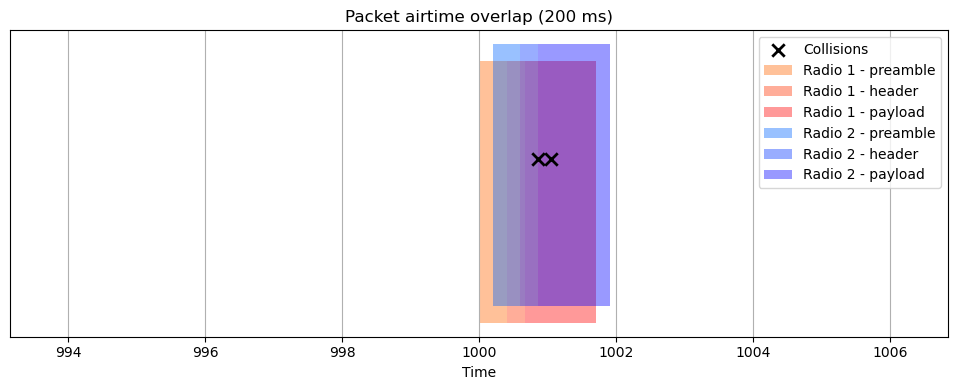

In [185]:
import matplotlib.pyplot as plt

phy_packets['stop_time'] = phy_packets['start_time'] + phy_packets['airtime']

plt.figure(figsize=(10, 4))

r1 = phy_packets[phy_packets['radio_id'] == 1]
r1 = r1[r1.index < 4]
r2 = phy_packets[phy_packets['radio_id'] == 2]
r2 = r2[r2.index < 4]

plt.barh(
    y=1,
    width=preamble_t,
    left=r1['start_time'],
    label="Radio 1 - preamble",
    color=(1,0.4,0,0.4)
)
plt.barh(
    y=1,
    width=header_t,
    left=r1['start_time'] + preamble_t,
    label="Radio 1 - header",
    color=(1,0.2,0,0.4)
)
plt.barh(
    y=1,
    width=r1['airtime'] - preamble_t - header_t,
    left=r1['start_time'] + preamble_t + header_t,
    label="Radio 1 - payload",
    color=(1,0,0,0.4)
)

plt.barh(
    y=1.05,
    width=preamble_t,
    left=r2['start_time'],
    label="Radio 2 - preamble",
    color=(0,0.4,1,0.4)
)
plt.barh(
    y=1.05,
    width=header_t,
    left=r2['start_time'] + preamble_t,
    label="Radio 2 - header",
    color=(0,0.2,1,0.4)
)
plt.barh(
    y=1.05,
    width=r2['airtime'] - preamble_t - header_t,
    left=r2['start_time'] + preamble_t + header_t,
    label="Radio 2 - payload",
    color=(0,0,1,0.4)
)


receiver_packets['airtime'] = phy_packets['airtime']
collisions = receiver_packets[receiver_packets['collision']]
plt.scatter(
    collisions['time'] - (collisions['airtime'] / 2),
    y=np.ones(len(collisions)) * 1.1,
    marker='x',
    s=80,
    linewidths=2,
    color='black',
    zorder=5,
    label="Collisions"
)

plt.xlabel("Time")
plt.xlim(
    phy_packets['start_time'].min() - phy_packets['airtime'].max() * 4,
    phy_packets['start_time'].min() + phy_packets['airtime'].max() * 4
)

plt.title(f"Packet airtime overlap ({offset_ms} ms)")
plt.tight_layout()
plt.grid()
plt.yticks([])

plt.legend()

plt.show()